In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [178]:
df = pd.read_csv(r"C:\Users\PRAVEEN\Project_2\Customer_Churn\data\Raw\customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [179]:
df.shape

(7043, 21)

In [180]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [181]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.values
})

dtype_df

,Column,Datatype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [182]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",'0')
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges']


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [183]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [184]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [185]:
val = len(df['customerID'].unique())
val


7043

In [186]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Target Variable Analysis

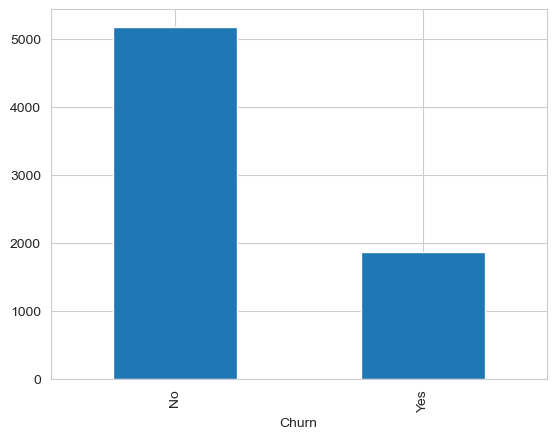

In [187]:
customer_churned = df.groupby('Churn')['customerID'].count().plot(kind = 'bar')
plt.show()

In [188]:
churn_percentage = round(1869/7043,2)
churn_percentage

0.27

In [189]:
customer_churned = df.groupby(['gender','Churn'])['customerID'].size().unstack()
# customer_churned
# plt.show()
customer_churned

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


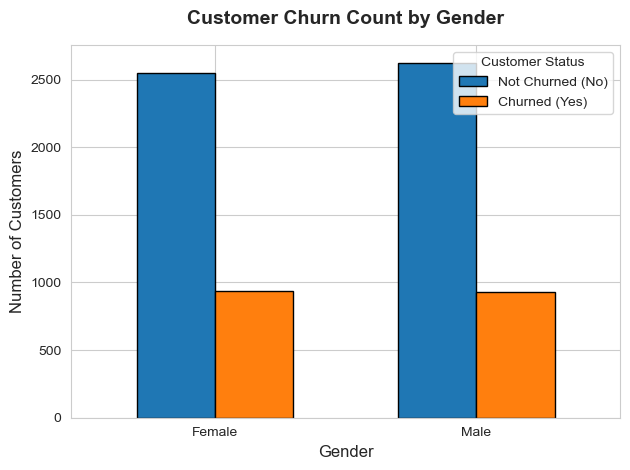

In [190]:
customer_churned.plot(kind='bar', edgecolor='black', width=0.6)


plt.title('Customer Churn Count by Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0) # Keeps 'Male' and 'Female' text horizontal


plt.legend(title='Customer Status', labels=['Not Churned (No)', 'Churned (Yes)'], loc='upper right')

# Add gridlines for readability
# plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [191]:
percent_of_churned = df.groupby('Churn')['customerID'].nunique()
percent_of_churned

Churn
No     5174
Yes    1869
Name: customerID, dtype: int64

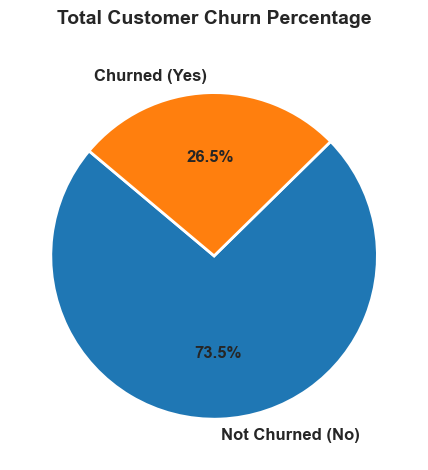

In [192]:
plt.pie(percent_of_churned,
    labels=['Not Churned (No)', 'Churned (Yes)'],
    autopct='%1.1f%%',       # Formats and displays the percentage automatically
    startangle=140,          # Rotates the starting angle for better visual alignment
    shadow=False, 
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} )


# 5. Add title and display
plt.title('Total Customer Churn Percentage', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

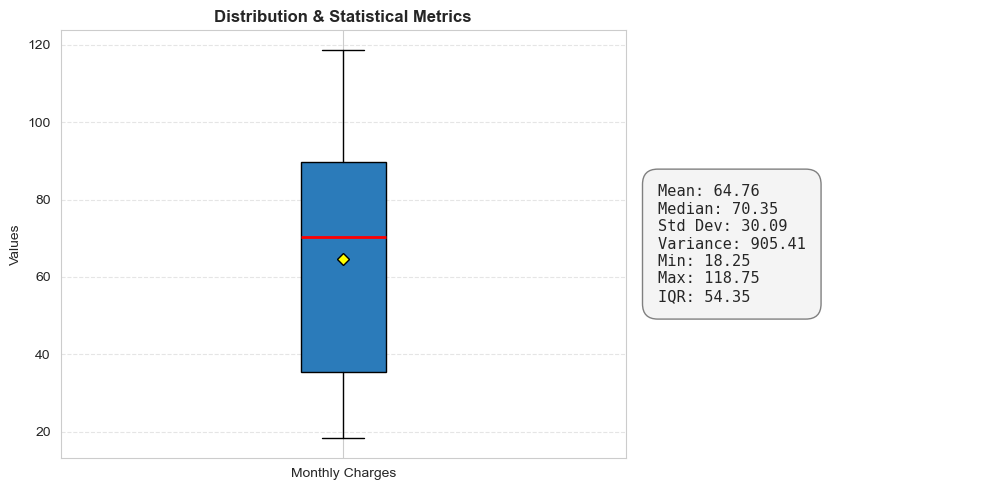

In [193]:
# Calculate all required metrics using Pandas/NumPy
values = df['MonthlyCharges']
q1 = values.quantile(0.25)
q3 = values.quantile(0.75)

metrics = {
    "Mean": values.mean(),
    "Median": values.median(),
    "Std Dev": values.std(),
    "Variance": values.var(),
    "Min": values.min(),
    "Max": values.max(),
    "IQR": q3 - q1
}

# Create the plot layout (1 row, 2 columns to separate plot and text)
fig, (ax_box, ax_text) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1.2]})

# Plot Box Plot (showMeans draws a point for the mean value)
ax_box.boxplot(values, vert=True, patch_artist=True, showmeans=True,
               boxprops=dict(facecolor='#2b7bba', color='black'),
               meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow'),
               medianprops=dict(color='red', linewidth=2))

ax_box.set_title('Distribution & Statistical Metrics', fontsize=12, fontweight='bold')
ax_box.set_ylabel('Values')
ax_box.set_xticklabels(['Monthly Charges'])
ax_box.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Build and display the text string for metrics
text_str = "\n".join([f"{k}: {v:.2f}" for k, v in metrics.items()])

# Turn off axis lines for the text panel
ax_text.axis('off') 
ax_text.text(0.05, 0.5, text_str, transform=ax_text.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1', facecolor='#f4f4f4', edgecolor='gray'))

plt.tight_layout()
plt.show()

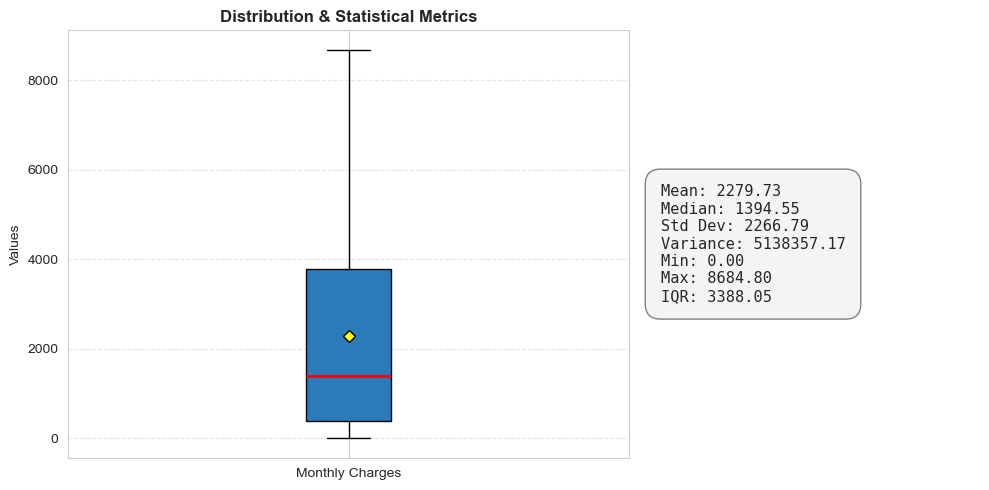

In [194]:
# Calculate all required metrics using Pandas/NumPy
values = df['TotalCharges']
q1 = values.quantile(0.25)
q3 = values.quantile(0.75)

metrics = {
    "Mean": values.mean(),
    "Median": values.median(),
    "Std Dev": values.std(),
    "Variance": values.var(),
    "Min": values.min(),
    "Max": values.max(),
    "IQR": q3 - q1
}

# Create the plot layout (1 row, 2 columns to separate plot and text)
fig, (ax_box, ax_text) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1.2]})

# Plot Box Plot (showMeans draws a point for the mean value)
ax_box.boxplot(values, vert=True, patch_artist=True, showmeans=True,
               boxprops=dict(facecolor='#2b7bba', color='black'),
               meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow'),
               medianprops=dict(color='red', linewidth=2))

ax_box.set_title('Distribution & Statistical Metrics', fontsize=12, fontweight='bold')
ax_box.set_ylabel('Values')
ax_box.set_xticklabels(['Monthly Charges'])
ax_box.grid(axis='y', linestyle='--', alpha=0.5)

# Build and display the text string for metrics
text_str = "\n".join([f"{k}: {v:.2f}" for k, v in metrics.items()])

# Turn off axis lines for the text panel
ax_text.axis('off') 
ax_text.text(0.05, 0.5, text_str, transform=ax_text.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1', facecolor='#f4f4f4', edgecolor='gray'))

plt.tight_layout()
plt.show()

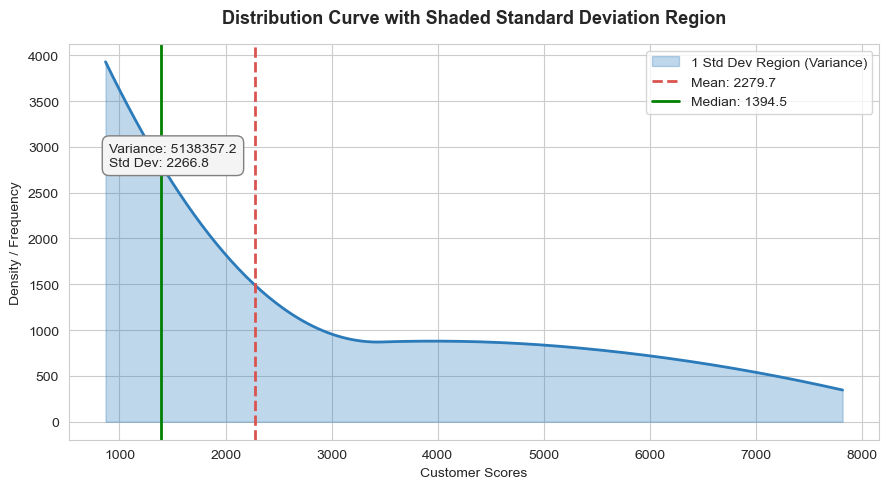

In [195]:
from scipy.interpolate import make_interp_spline

# Calculate the key statistical metrics
mean_val = df['TotalCharges'].mean()
median_val = df['TotalCharges'].median()
std_val = df['TotalCharges'].std()
variance_val = df['TotalCharges'].var()

# Create a smooth distribution curve using a histogram's values
counts, bins = np.histogram(df['TotalCharges'], bins=5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Interpolate to make the curve perfectly smooth
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
spline = make_interp_spline(bin_centers, counts, k=2)
y_smooth = spline(x_smooth).clip(min=0) # clip prevents line from dipping below 0

#Plotting
plt.figure(figsize=(9, 5))

# Plot the main smooth curve outline
plt.plot(x_smooth, y_smooth, color='#2b7bba', linewidth=2)



plt.fill_between(
    x_smooth, y_smooth, 
    # where=((x_smooth > lower_std) & (x_smooth < upper_std)), 
    color='#2b7bba', alpha=0.3, label='1 Std Dev Region (Variance)'
)

# Add vertical lines for Mean and Median
plt.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')

# Add text metadata card for exact metrics on the chart
text_box_str = f"Variance: {variance_val:.1f}\nStd Dev: {std_val:.1f}"
plt.text(
    0.05, 0.75, text_box_str, transform=plt.gca().transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='gray')
)

# Formatting labels, legends, and titles
plt.title('Distribution Curve with Shaded Standard Deviation Region', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Scores')
plt.ylabel('Density / Frequency')
plt.legend(loc='upper right')
# plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

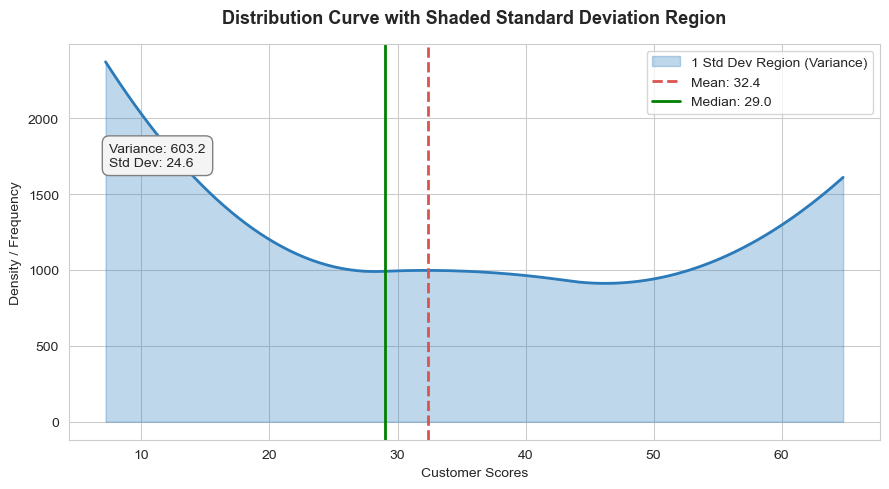

In [196]:
from scipy.interpolate import make_interp_spline

# Calculate the key statistical metrics
mean_val = df['tenure'].mean()
median_val = df['tenure'].median()
std_val = df['tenure'].std()
variance_val = df['tenure'].var()

# Create a smooth distribution curve using a histogram's values
counts, bins = np.histogram(df['tenure'], bins=5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Interpolate to make the curve perfectly smooth
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
spline = make_interp_spline(bin_centers, counts, k=2)
y_smooth = spline(x_smooth).clip(min=0) # clip prevents line from dipping below 0

#Plotting
plt.figure(figsize=(9, 5))

# Plot the main smooth curve outline
plt.plot(x_smooth, y_smooth, color='#2b7bba', linewidth=2)



plt.fill_between(
    x_smooth, y_smooth, 
    # where=((x_smooth > lower_std) & (x_smooth < upper_std)), 
    color='#2b7bba', alpha=0.3, label='1 Std Dev Region (Variance)'
)

# Add vertical lines for Mean and Median
plt.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')

# Add text metadata card for exact metrics on the chart
text_box_str = f"Variance: {variance_val:.1f}\nStd Dev: {std_val:.1f}"
plt.text(
    0.05, 0.75, text_box_str, transform=plt.gca().transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='gray')
)

# Formatting labels, legends, and titles
plt.title('Distribution Curve with Shaded Standard Deviation Region', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Scores')
plt.ylabel('Density / Frequency')
plt.legend(loc='upper right')
# plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

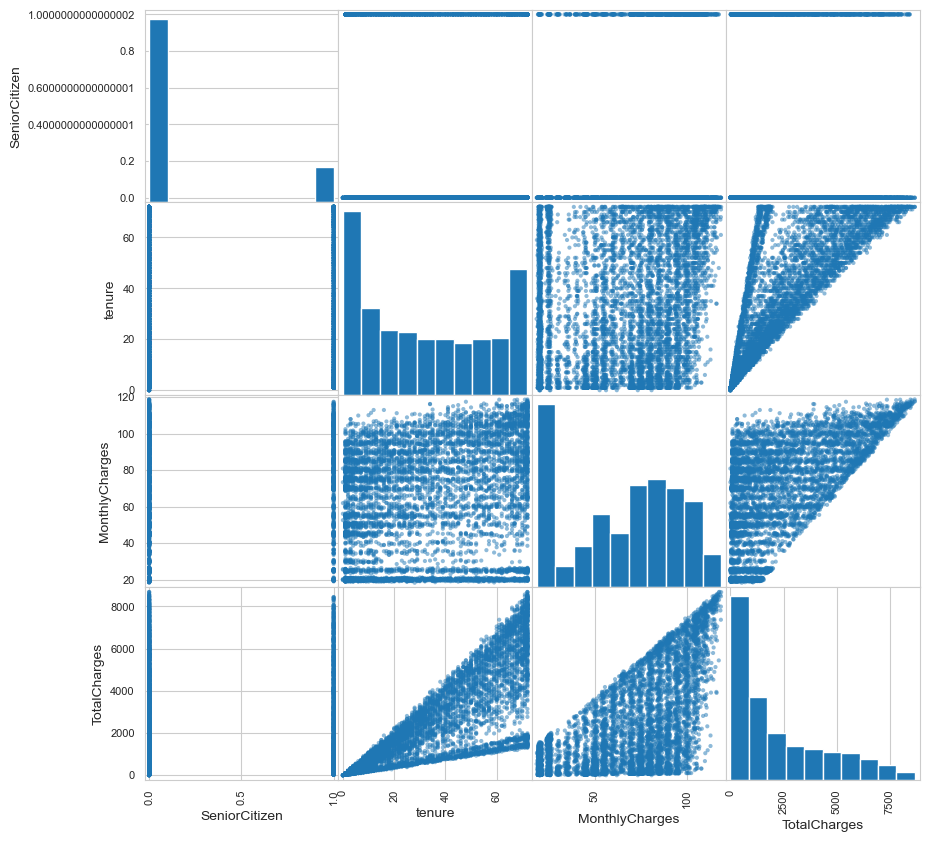

In [197]:
scatter_matrix(df, figsize=(10, 10), diagonal='hist')

# 3. Display the plot
plt.show()

In [198]:
missing_values = df.isnull().sum()

missing_df = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .to_frame(name="Missing Count")
)

missing_df["Missing %"] = (
    missing_df["Missing Count"] / len(df) * 100
).round(2)

missing_df


,Missing Count,Missing %


#### Duplicate Values

In [199]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [200]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#### Unique Values

In [201]:
unique_counts = pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values")

unique_counts

,Unique Values
Churn,2
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PaperlessBilling,2
PhoneService,2
Contract,3
StreamingMovies,3
StreamingTV,3


In [202]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [203]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [204]:
dtype_df

,Column,Datatype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [205]:
dtype_df.loc[dtype_df['Column'] == 'TotalCharges', 'Datatype'] = 'float64'

In [206]:
df['TotalCharges'].dtype

dtype('float64')

In [207]:
Numerical_Cols, Catergorical_Cols = [],[]

for value,key in zip(dtype_df['Datatype'],dtype_df['Column']):
    if value=='object':
        Catergorical_Cols.append(key)
    else:
        Numerical_Cols.append(key)
print("Numerical Columns: ", Numerical_Cols)
print('Catergorical Columns: ', Catergorical_Cols)

Numerical Columns:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Catergorical Columns:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


#### Data Quality Summary

- Dataset Shape: 7043 Rows X 21 Columns
- Missing Values: 0 
- Duplicate Records: 0
- Constant Columns: 0
- Numeric Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
- Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
- Total Memory Usage:
- Data Quality Issues Observed: Changed the datatype TotalCharges, filled missing values with '0' as basic excecise.

In [208]:
def analyze_numeric_features(df, column):

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Histogram
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30,
        ax=axes[0]
    )

    axes[0].set_title(f"Distribution of {column}")

    # Boxplot
    sns.boxplot(
        x=df[column],
        ax=axes[1]
    )

    axes[1].set_title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

    print(df[column].describe())
    print("Skewness:", df[column].skew())

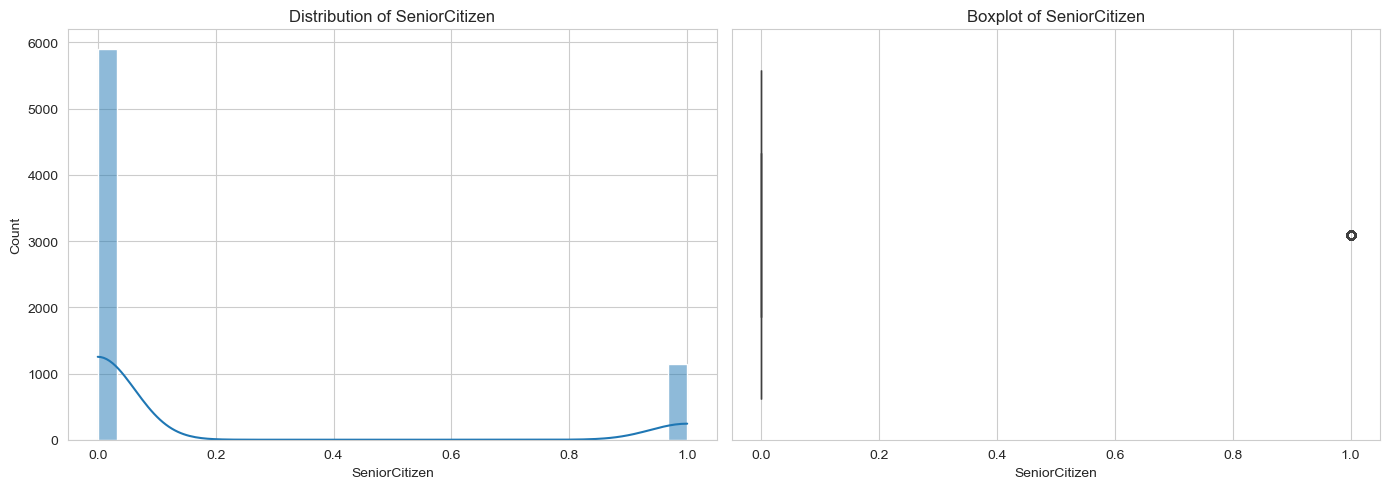

count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64
Skewness: 1.8336327440928564


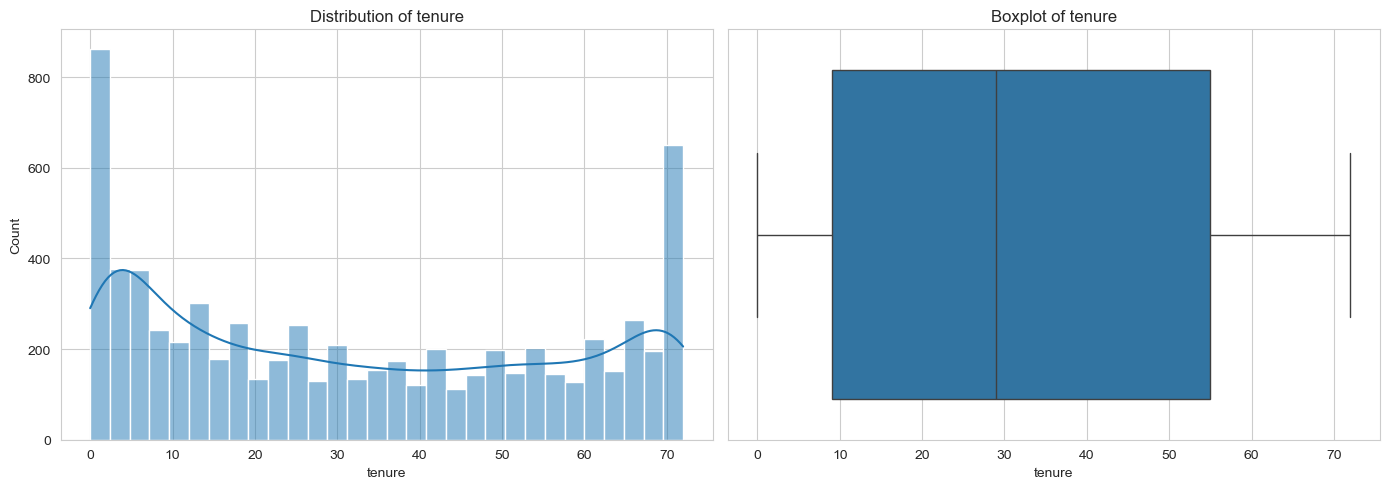

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness: 0.2395397495619829


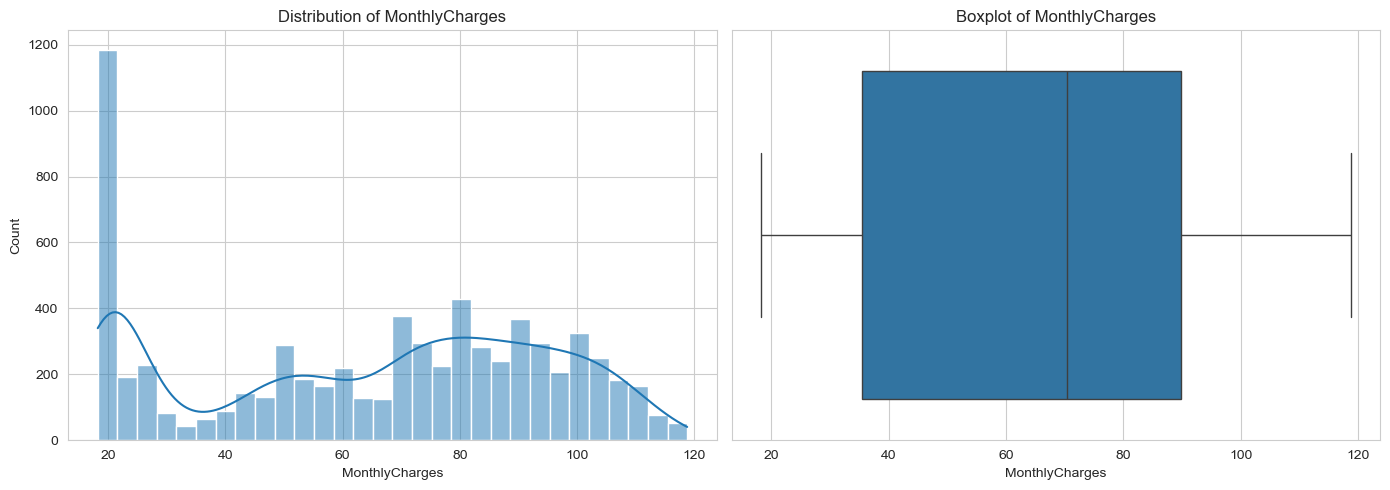

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness: -0.22052443394398033


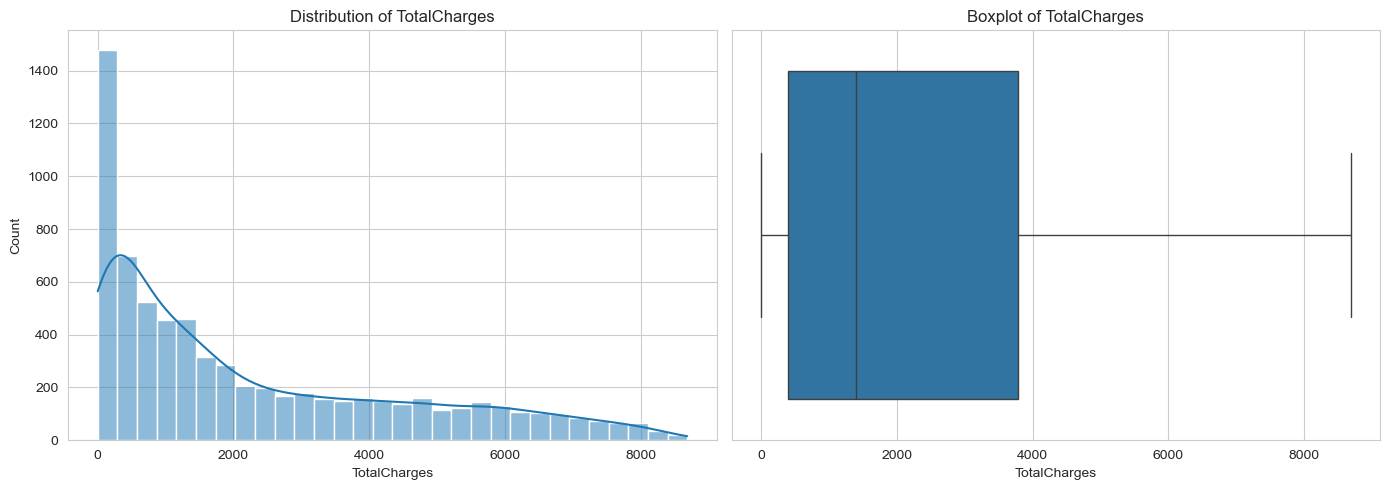

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness: 0.963234654832277


In [209]:
for col in Numerical_Cols:
    analyze_numeric_features(df, col)

### BiVariate Analysis

In [210]:
# Lets check the Churn Percentage

(df['Churn'].value_counts(normalize=True)*100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [211]:
New_Numerical_Cols = Numerical_Cols[1:]
New_Numerical_Cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [216]:
New_Categorical_Cols = Catergorical_Cols
New_Categorical_Cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']